# 02 — Tabular-only MLP Baseline (M1)

### Contents
- A. Data loading & feature prep
- B. Model (Keras Functional API)
- C. Training (EarlyStopping + ReduceLROnPlateau)
- D. Evaluation & metrics
- E. Error analysis
- F. Save model

In [ ]:
import os
from google.colab import drive

# connecting Google Drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/OzU/DeepLearning/Project'

# coping images.zip into local SSD Colab and unzipping
if not os.path.exists('/content/Images'):
    print('coping...')
    !cp "{DRIVE_DIR}/images.zip" /content/images.zip
    print('Unzipping...')
    !unzip -q /content/images.zip -d /content/
    !rm /content/images.zip
    print(f'Done. Images: {len(os.listdir("/content/Images"))}')
else:
    print('Images уже распакованы.')

BASE_DIR = '/content'
DATA_DIR = DRIVE_DIR
IMAGES_DIR = '/content/Images'
CLEAN_CSV = os.path.join(DATA_DIR, 'data_clean.csv')
CKPT_DIR = os.path.join(DRIVE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

print('BASE_DIR:', BASE_DIR)
print('DATA_DIR:', DATA_DIR)
print('CKPT_DIR:', CKPT_DIR)

Mounted at /content/drive
coping...
Unzipping...
Done. Images: 24053
BASE_DIR: /content
DATA_DIR: /content/drive/MyDrive/OzU/DeepLearning/Project
CKPT_DIR: /content/drive/MyDrive/OzU/DeepLearning/Project/checkpoints


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))
print('CLEAN_CSV:', CLEAN_CSV)

TensorFlow: 2.20.0
GPU available: True
CLEAN_CSV: /content/drive/MyDrive/OzU/DeepLearning/Project/data_clean.csv


---
## A. Data Loading & Feature Preparation

In [ ]:
df = pd.read_csv(CLEAN_CSV, encoding='utf-8-sig')

df['photo_rel'] = df['photo_rel'].str.replace(
    'Data/Istanbul/Images', 'Images', regex=False
)

print(f'Total rows: {len(df):,}  |  columns: {len(df.columns)}')
print(df['split'].value_counts().to_string())

Total rows: 22,543  |  columns: 51
split
train    15780
test      3382
val       3381


In [ ]:
ILCE_COLS = [c for c in df.columns if c.startswith('ilce_')]
TAB_FEATURES = ['area_scaled', 'rooms_scaled'] + ILCE_COLS
TARGET = 'log_price'

df_train = df[df['split'] == 'train'].reset_index(drop=True)
df_val = df[df['split'] == 'val'].reset_index(drop=True)
df_test = df[df['split'] == 'test'].reset_index(drop=True)

X_train = df_train[TAB_FEATURES].values.astype(np.float32)
y_train = df_train[TARGET].values.astype(np.float32)
X_val = df_val[TAB_FEATURES].values.astype(np.float32)
y_val = df_val[TARGET].values.astype(np.float32)
X_test = df_test[TAB_FEATURES].values.astype(np.float32)
y_test = df_test[TARGET].values.astype(np.float32)

print(f'Input dim: {len(TAB_FEATURES)} features')
print(f'Train: {X_train.shape}  {y_train.shape}')
print(f'Val: {X_val.shape}    {y_val.shape}')
print(f'Test: {X_test.shape}   {y_test.shape}')

Input dim: 41 features
Train: (15780, 41)  (15780,)
Val: (3381, 41)    (3381,)
Test: (3382, 41)   (3382,)


---
## B. Model — Keras Functional API

In [ ]:
def build_mlp(n_features: int, dropout: float = 0.3,
               lr: float = 1e-3) -> keras.Model:
    """
    M1 - Tabular MLP (Keras Functional API)

    Input(n_features)
      -> Dense(256) -> BatchNorm -> ReLU -> Dropout(0.3)
      -> Dense(128) -> BatchNorm -> ReLU -> Dropout(0.3)
      -> Dense(64)  -> BatchNorm -> ReLU -> Dropout(0.2)
      -> Dense(1)   [log_price]

    Loss: Huber (coef delta=1.0) - robust to price outliers
    """
    inputs = keras.Input(shape=(n_features,), name='tabular_input')

    # Block 1
    x = layers.Dense(256, use_bias=False, name='dense_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(dropout, name='drop_1')(x)

    # Block 2
    x = layers.Dense(128, use_bias=False, name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(dropout, name='drop_2')(x)

    # Block 3
    x = layers.Dense(64, use_bias=False, name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Activation('relu', name='relu_3')(x)
    x = layers.Dropout(dropout, name='drop_3')(x)

    # Output
    output = layers.Dense(1, name='output')(x)

    model = keras.Model(inputs=inputs, outputs=output, name='MLP_M1')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.Huber(delta=1.0),
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')]
    )
    return model


model = build_mlp(n_features=len(TAB_FEATURES))
model.summary()

Model: "MLP_M1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tabular_input (InputLayer)      │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,313 (208.25 KB)

 Trainable params: 52,417 (204.75 KB)

 Non-trainable params: 896 (3.50 KB)

---
## C. Training

In [ ]:
CKPT_PATH = os.path.join(CKPT_DIR, 'mlp_m1_best.keras')

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10,
        min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        CKPT_PATH, monitor='val_loss',
        save_best_only=True, verbose=0
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 4.7899 - mae: 5.2734 - val_loss: 4.2151 - val_mae: 4.7151 - learning_rate: 0.0010
Epoch 2/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0047 - mae: 1.4308 - val_loss: 0.4448 - val_mae: 0.8825 - learning_rate: 0.0010
Epoch 3/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8639 - mae: 1.2821 - val_loss: 0.2589 - val_mae: 0.6079 - learning_rate: 0.0010
Epoch 4/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7847 - mae: 1.1979 - val_loss: 0.1298 - val_mae: 0.4156 - learning_rate: 0.0010
Epoch 5/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7249 - mae: 1.1322 - val_loss: 0.1157 - val_mae: 0.3949 - learning_rate: 0.0010
Epoch 6/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6810 - mae: 1.0866 - val_loss: 0.1151 - val_mae: 0.3742 - learning_rate: 0.0010
Epoch 7/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6319 - mae: 1.0314 - val_loss: 0.0993 - val_mae: 0.3648 - learning_rate: 0.00

### C1. Learning curves

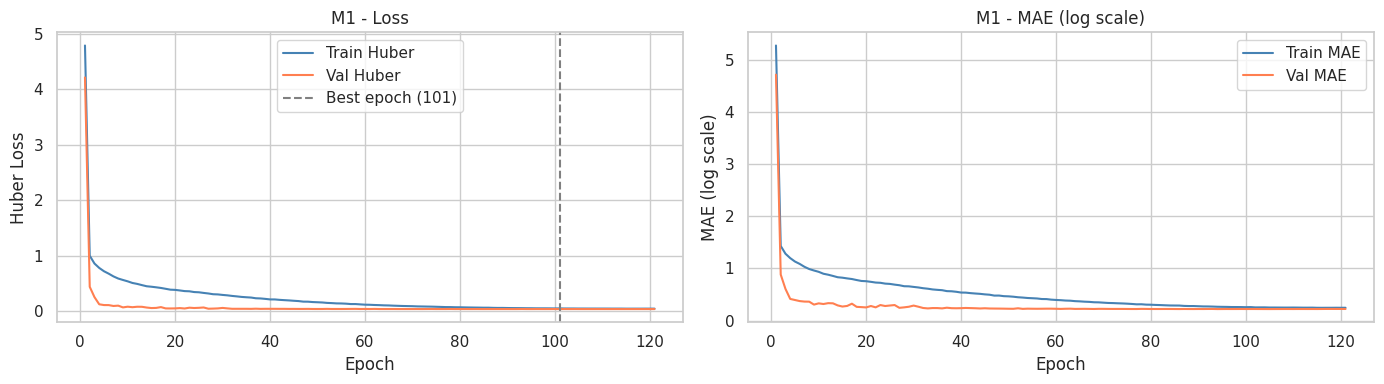

Best epoch: 101 | Best val Huber: 0.04361


In [ ]:
hist = history.history
epochs = range(1, len(hist['loss']) + 1)
best_ep = np.argmin(hist['val_loss']) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, hist['loss'],     label='Train Huber', color='steelblue')
axes[0].plot(epochs, hist['val_loss'], label='Val Huber',   color='coral')
axes[0].axvline(best_ep, color='grey', ls='--', label=f'Best epoch ({best_ep})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].set_title('M1 - Loss')
axes[0].legend()

axes[1].plot(epochs, hist['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(epochs, hist['val_mae'], label='Val MAE',   color='coral')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (log scale)')
axes[1].set_title('M1 - MAE (log scale)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'm1_learning_curves.png'), bbox_inches='tight')
plt.show()
print(f'Best epoch: {best_ep} | Best val Huber: {min(hist["val_loss"]):.5f}')

---
## D. Evaluation & Metrics

In [ ]:
def evaluate(model, X, y_log, split_name=''):
    """Predict and compute metrics on the original TL scale."""
    preds_log  = model.predict(X, verbose=0).flatten()
    preds_tl   = np.expm1(preds_log)
    targets_tl = np.expm1(y_log)

    mae  = mean_absolute_error(targets_tl, preds_tl)
    rmse = np.sqrt(mean_squared_error(targets_tl, preds_tl))
    r2   = r2_score(targets_tl, preds_tl)
    mape = np.mean(np.abs((targets_tl - preds_tl) / targets_tl)) * 100
    huber = float(model.evaluate(X, y_log, verbose=0)[0])

    print(f'\n --- {split_name} ---')
    print(f'  MAE        : {mae:>10,.0f} TL')
    print(f'  RMSE       : {rmse:>10,.0f} TL')
    print(f'  MAPE       : {mape:>10.2f} %')
    print(f'  R²         : {r2:>10.4f}')
    print(f'  Huber loss : {huber:>10.5f}')

    return dict(MAE=mae, RMSE=rmse, MAPE=mape, R2=r2, Huber=huber,
                preds_tl=preds_tl, targets_tl=targets_tl)


val_m  = evaluate(model, X_val,  y_val,  'Validation')
test_m = evaluate(model, X_test, y_test, 'Test')


 --- Validation ---
  MAE        :      7,194 TL
  RMSE       :      9,265 TL
  MAPE       :      24.64 %
  R²         :     0.4085
  Huber loss :    0.04361

 --- Test ---
  MAE        :      7,247 TL
  RMSE       :      9,340 TL
  MAPE       :      24.01 %
  R²         :     0.3726
  Huber loss :    0.04227


In [ ]:
results_df = pd.DataFrame({
    'Split':      ['Validation', 'Test'],
    'MAE (TL)':   [val_m['MAE'],   test_m['MAE']],
    'RMSE (TL)':  [val_m['RMSE'],  test_m['RMSE']],
    'MAPE (%)':   [val_m['MAPE'],  test_m['MAPE']],
    'R²':         [val_m['R2'],    test_m['R2']],
    'Huber loss': [val_m['Huber'], test_m['Huber']],
}).set_index('Split').round({'MAE (TL)': 0, 'RMSE (TL)': 0,
                              'MAPE (%)': 2, 'R²': 4, 'Huber loss': 5})
# display(results_df)
results_df.to_csv(os.path.join(DATA_DIR, 'm1_metrics.csv'))
print('Saved → m1_metrics.csv')

Saved → m1_metrics.csv


---
## E. Error Analysis

### E1. Predicted vs Actual

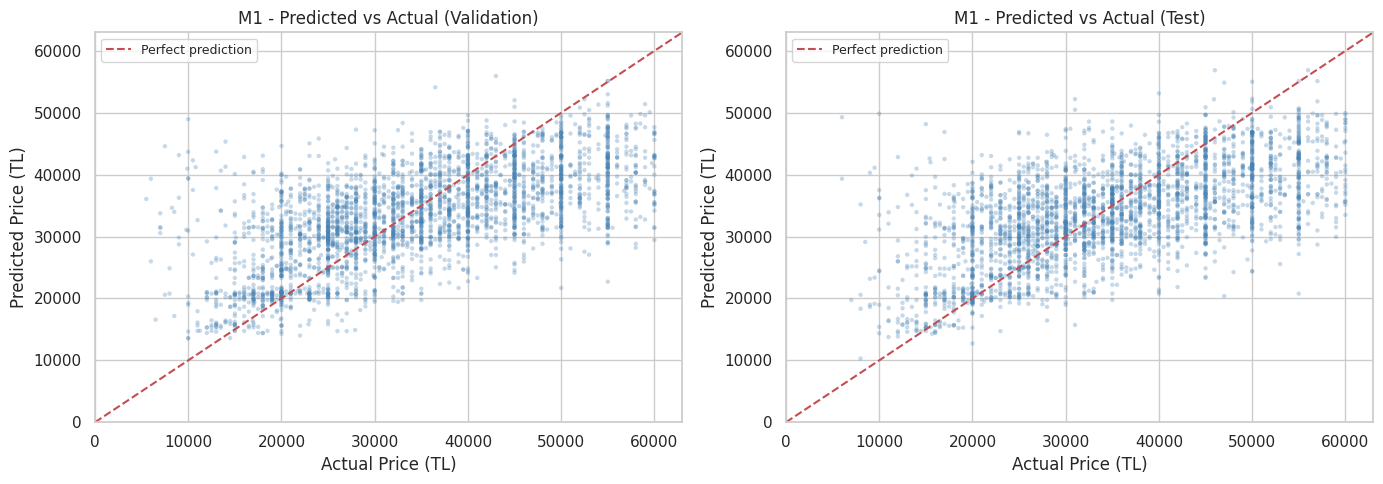

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (m, name) in zip(axes, [(val_m, 'Validation'), (test_m, 'Test')]):
    mx = max(m['targets_tl'].max(), m['preds_tl'].max()) * 1.05
    ax.scatter(m['targets_tl'], m['preds_tl'],
               alpha=0.3, s=10, color='steelblue', edgecolors='none')
    ax.plot([0, mx], [0, mx], 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlim(0, mx); ax.set_ylim(0, mx)
    ax.set_xlabel('Actual Price (TL)')
    ax.set_ylabel('Predicted Price (TL)')
    ax.set_title(f'M1 - Predicted vs Actual ({name})')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'm1_pred_vs_actual.png'), bbox_inches='tight')
plt.show()

### E2. Residuals

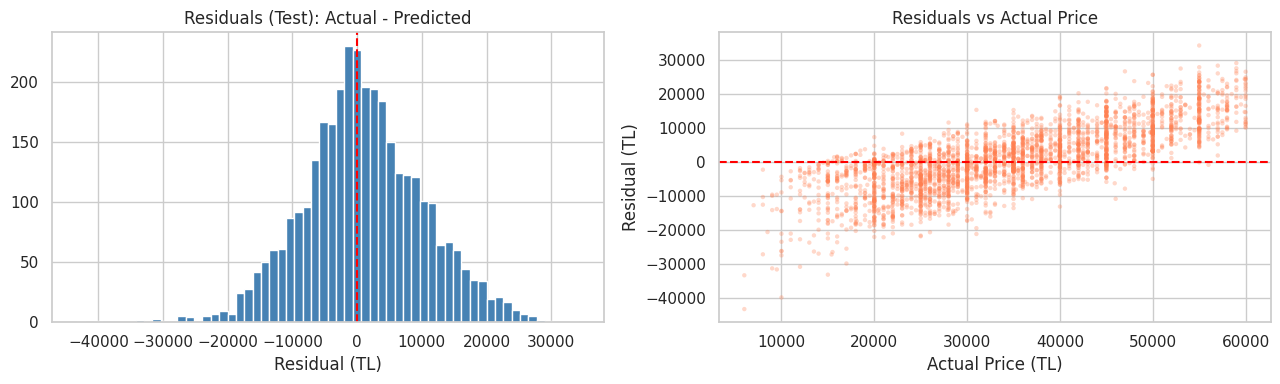

Residuals - mean: 1,005 TL  std: 9,286 TL


In [ ]:
residuals = test_m['targets_tl'] - test_m['preds_tl']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', ls='--')
axes[0].set_title('Residuals (Test): Actual - Predicted')
axes[0].set_xlabel('Residual (TL)')

axes[1].scatter(test_m['targets_tl'], residuals,
                alpha=0.3, s=10, color='coral', edgecolors='none')
axes[1].axhline(0, color='red', ls='--')
axes[1].set_xlabel('Actual Price (TL)')
axes[1].set_ylabel('Residual (TL)')
axes[1].set_title('Residuals vs Actual Price')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'm1_residuals.png'), bbox_inches='tight')
plt.show()
print(f'Residuals - mean: {residuals.mean():,.0f} TL  std: {residuals.std():,.0f} TL')

### E3. Error by İlçe

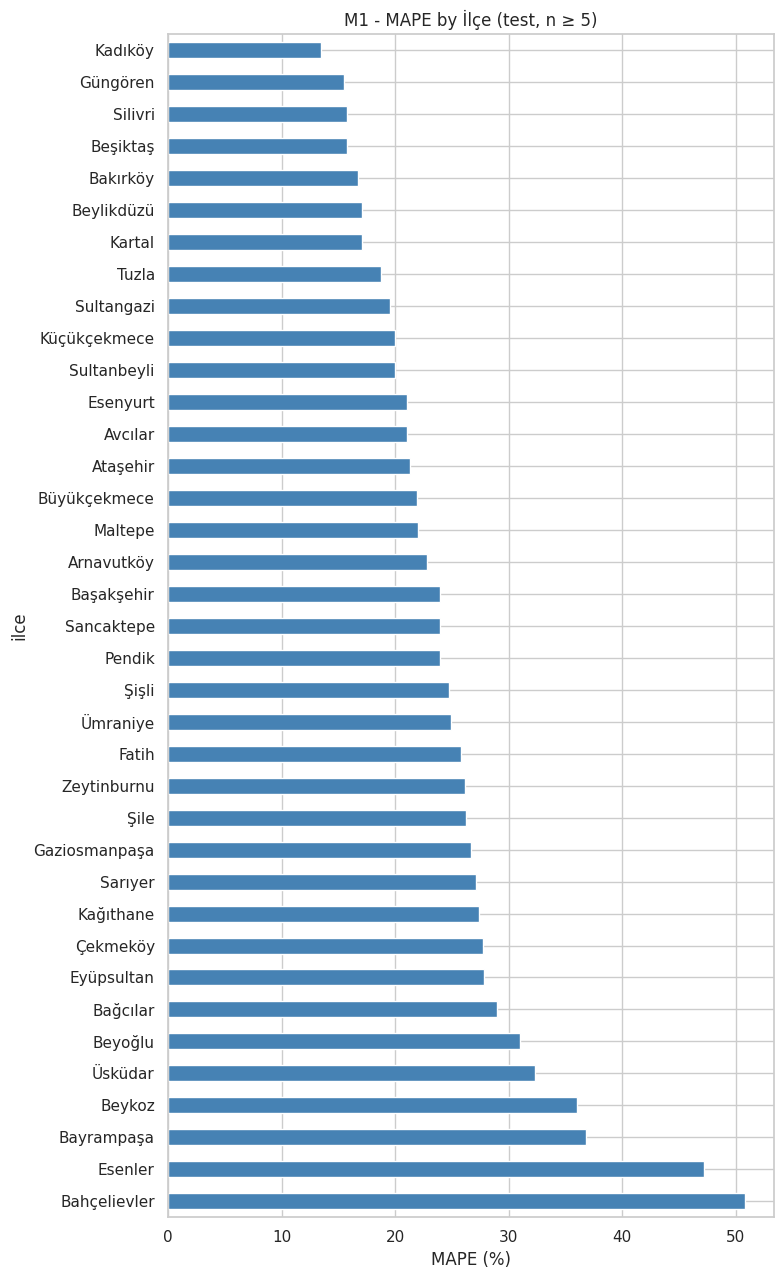

,n,mae,mape
ilce,,,
Kadıköy,87,4903.4,13.5
Güngören,7,6757.7,15.5
Silivri,55,5038.1,15.7
Beşiktaş,64,6225.8,15.7
Bakırköy,20,5047.0,16.8
Beylikdüzü,93,5929.3,17.1
Kartal,73,6389.2,17.1
Tuzla,115,6246.0,18.8
Sultangazi,18,7002.9,19.5


In [ ]:
df_err = df_test[['ilce', 'Price']].copy()
df_err['pred'] = test_m['preds_tl']
df_err['abs_err'] = np.abs(df_err['Price'] - df_err['pred'])
df_err['pct_err'] = df_err['abs_err'] / df_err['Price'] * 100

ilce_err = (
    df_err.groupby('ilce')
    .agg(n=('Price','count'), mae=('abs_err','mean'), mape=('pct_err','mean'))
    .query('n >= 5').sort_values('mape')
)

ilce_err['mape'].plot(kind='barh', figsize=(8, max(5, len(ilce_err)*0.35)),
                      color='steelblue')
plt.title('M1 - MAPE by İlçe (test, n ≥ 5)')
plt.xlabel('MAPE (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
display(ilce_err.round(1).head(10))

---
## F. Save Model

In [ ]:
model.save(CKPT_PATH)
print(f'Model saved into {CKPT_PATH}')

# Save feature list for notebook 3
import json
meta = {'tab_features': TAB_FEATURES, 'n_features': len(TAB_FEATURES),
        'test_mae': float(test_m['MAE']), 'test_r2': float(test_m['R2'])}
with open(os.path.join(CKPT_DIR, 'mlp_m1_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print('Metadata saved into mlp_m1_meta.json')

Model saved into /content/drive/MyDrive/OzU/DeepLearning/Project/checkpoints/mlp_m1_best.keras
Metadata saved into mlp_m1_meta.json


In [ ]:
print('=' * 58)
print('M1 - TABULAR MLP BASELINE  (test results)')
print('=' * 58)
print(f'  Framework    : TensorFlow {tf.__version__} / Keras Functional API')
print(f'  Architecture : Input({len(TAB_FEATURES)}) → 256 → 128 → 64 → 1')
print(f'  Loss         : Huber (delta=1.0)')
print(f'  Best epoch   : {best_ep}')
print()
print(f'  MAE          : {test_m["MAE"]:>10,.0f} TL')
print(f'  RMSE         : {test_m["RMSE"]:>10,.0f} TL')
print(f'  MAPE         : {test_m["MAPE"]:>10.2f} %')
print(f'  R²           : {test_m["R2"]:>10.4f}')
print('=' * 58)

M1 - TABULAR MLP BASELINE  (test results)
  Framework    : TensorFlow 2.20.0 / Keras Functional API
  Architecture : Input(41) → 256 → 128 → 64 → 1
  Loss         : Huber (delta=1.0)
  Best epoch   : 101

  MAE          :      7,247 TL
  RMSE         :      9,340 TL
  MAPE         :      24.01 %
  R²           :     0.3726


---
## G. Hyperparameter Sensitivity — Dropout Rate

We train M1 with three dropout values to justify the chosen regularisation strength.
All other settings are fixed: architecture 256→128→64, Huber loss, Adam lr=1e-3, batch_size=64.
The ★ row reuses the model already trained in Section C (no extra compute).

In [ ]:
def _sweep_train(d1, label):
    """Train a temporary M1 and return test metrics."""
    m_tmp = build_mlp(len(TAB_FEATURES), dropout=d1, lr=1e-3)
    m_tmp.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100, batch_size=64,
        callbacks=[callbacks.EarlyStopping(
            monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)],
        verbose=0
    )
    p   = np.expm1(m_tmp.predict(X_test, verbose=0).flatten())
    tgt = np.expm1(y_test)
    print(f'  {label}: MAE={mean_absolute_error(tgt, p):,.0f} TL  '
          f'R²={r2_score(tgt, p):.4f}')
    return dict(
        dropout = d1,
        test_mae = int(mean_absolute_error(tgt, p)),
        test_mape = round(np.mean(np.abs((tgt - p) / tgt)) * 100, 2),
        test_r2  = round(r2_score(tgt, p), 4),
    )

print('Running dropout sweep (configs A and C only; ★ reuses Section-C model)...')
cfg_a = _sweep_train(0.2, 'dropout=0.2')
cfg_c = _sweep_train(0.4, 'dropout=0.4')

# ★ config — reuse already-trained model from Section C
cfg_b = dict(
    dropout = 0.3,
    test_mae = int(test_m['MAE']),
    test_mape = round(test_m['MAPE'], 2),
    test_r2 = round(test_m['R2'], 4),
)

sweep_df = pd.DataFrame([cfg_a, cfg_b, cfg_c])
sweep_df.insert(0, 'Config', ['dropout=0.2', 'dropout=0.3  ★', 'dropout=0.4'])
sweep_df = sweep_df.drop(columns='dropout').set_index('Config')
sweep_df.columns = ['Test MAE (TL)', 'Test MAPE (%)', 'Test R²']

print('\nDropout Sensitivity - M1 (test set):')
display(sweep_df)

Running dropout sweep (configs A and C only; ★ reuses Section-C model)...
  dropout=0.2: MAE=7,419 TL  R²=0.3499
  dropout=0.4: MAE=7,333 TL  R²=0.3604

Dropout Sensitivity - M1 (test set):


,Test MAE (TL),Test MAPE (%),Test R²
Config,,,
dropout=0.2,7418,24.719999,0.3499
dropout=0.3 ★,7246,24.010000,0.3726
dropout=0.4,7333,24.200001,0.3604


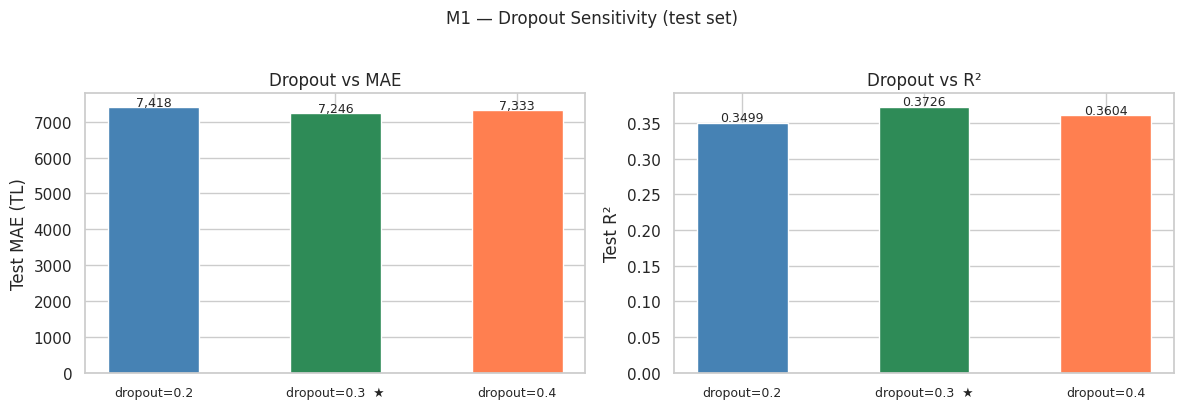

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = range(len(sweep_df))
xlabels = sweep_df.index.tolist()
colors = ['steelblue', 'seagreen', 'coral']

axes[0].bar(x, sweep_df['Test MAE (TL)'], color=colors, edgecolor='white', width=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(xlabels, fontsize=9)
axes[0].set_ylabel('Test MAE (TL)'); axes[0].set_title('Dropout vs MAE')
for i, v in enumerate(sweep_df['Test MAE (TL)']):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=9)

axes[1].bar(x, sweep_df['Test R²'], color=colors, edgecolor='white', width=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(xlabels, fontsize=9)
axes[1].set_ylabel('Test R²'); axes[1].set_title('Dropout vs R²')
for i, v in enumerate(sweep_df['Test R²']):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('M1 — Dropout Sensitivity (test set)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'm1_dropout_sweep.png'), bbox_inches='tight')
plt.show()